# The Linear Regression Channel slope — a quantitative teardown 🔬
### Rolling-OLS log-price slope as a long/flat timing rule · NET, excess-vs-excess vs buy-and-hold · HAC *t* on the active return · block-permutation placebo · head-to-head vs an SMA filter · cost & window sweeps · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_moving_average%3F: Not_Supported](https://img.shields.io/badge/Beats_a_moving_average%3F-Not_Supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The LRC slope is sold as a *leading, smoother* trend read than a moving average. We show it is neither: it is a lagging weighted average of recent returns, its edge over buy-and-hold is **indistinguishable from zero** (HAC *t* < 0), and it is **no better** than the SMA rule it claims to replace.

> ⚠️ **Data note.** SPY **total-return** (auto-adjusted) daily closes via yfinance, cache-first; small panel (SPY/QQQ/AAPL/MSFT/JPM/XLE) for the cross-instrument check. One execution lag (signal at close *t* earns return *t+1*). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from linear_regression_channel import data, strategy as st

HAVE_REAL = data.have_real("SPY")
if HAVE_REAL:
    SPY = data.load_real("SPY", fetch=False)
    CLOSE = SPY["close"]
else:
    SPY = CLOSE = None
print("real SPY cache present:", HAVE_REAL,
      "| bars:", (0 if CLOSE is None else len(CLOSE)))

# frozen headline numbers (mirror of docs/results.md)
R = {'ticker': 'SPY', 'start': '2005-01-03', 'end': '2026-06-12', 'n_days': 5395, 'years': 21.4, 'fingerprint': 'aeda2bbca066', 'window': 60, 'cost_bps': 1.0, 'sharpe_bh': 0.647, 'cagr_bh': 11.08, 'slope': {'sharpe': 0.711, 'gap': 0.063, 'active_t': -1.51, 'tim': 72, 'turn_yr': 3.26, 'cagr_net': 7.81}, 'sma': {'sharpe': 0.604, 'gap': -0.043, 'active_t': -2.03, 'tim': 72, 'turn_yr': 15.92, 'cagr_net': 6.17}, 'perm_obs_bps': -1.641, 'perm_p': 0.676, 'cost': [(0.0, 0.713, 0.066, -1.5), (0.5, 0.712, 0.065, -1.51), (1.0, 0.711, 0.063, -1.51), (2.0, 0.708, 0.061, -1.53), (5.0, 0.699, 0.052, -1.56)], 'win': [(20, 0.552, -0.093, -2.23), (40, 0.465, -0.175, -2.44), (60, 0.711, 0.063, -1.51), (100, 0.595, -0.053, -1.91), (200, 0.711, 0.058, -1.03)], 'longshort': (0.205, -0.442, -1.54), 'panel': [('SPY', 0.711, 0.647, 0.063, -1.51), ('QQQ', 0.56, 0.793, -0.233, -3.01), ('AAPL', 0.959, 0.963, -0.004, -1.82), ('MSFT', 0.543, 0.683, -0.14, -2.36), ('JPM', 0.31, 0.543, -0.234, -2.51), ('XLE', 0.168, 0.404, -0.236, -1.96)], 'panel_beat': 1, 'panel_n': 6, 'syn': [(0.0, -0.028, 0.112, -0.14, -0.72, 0.714), (0.5, 2.263, 1.556, 0.706, 2.44, 0.0)]}


real SPY cache present: True | bars: 5395


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Slope-rule daily **active** return (net, minus buy-and-hold) has HAC **t = -1.51** and block-permutation **p = 0.68** — nowhere near +2, and *negative*. Beats buy-and-hold on **1/6** names. |
| **Tradability** | `MIRAGE` | SPY net Sharpe **0.71** vs buy-and-hold **0.65** — a +0.06 gap that is not significant, inverts cross-section, and collapses long/short (Sharpe 0.20). |
| **Beats a moving average?** | `NOT SUPPORTED` | SMA rule active **t = -2.03** vs slope **-1.51** — both sub-zero; the slope's only difference is **lower turnover** (3.3 vs 15.9/yr), not edge. |

> 💡 In plain words: a least-squares slope of the last 60 log-prices is a lagging linear filter of recent returns. It neither beats the index nor improves on a moving average — its smoothness lowers turnover, which is not the same as adding return.

## 1 · The claim, steelmanned

Let $p_t=\log C_t$. The LRC centre-line is the OLS fit of $p$ on a time index over a window $W$; its **slope** is

$$\hat\beta_t = \frac{\sum_{k=0}^{W-1}(k-\bar k)\,(p_{t-W+1+k}-\bar p)}{\sum_k (k-\bar k)^2}= \frac{12}{W(W^2-1)}\sum_{k}(k-\bar k)\,p_{t-W+1+k}.$$

The timing rule is $x_t=\mathbb 1[\hat\beta_t>0]$ (long/flat) or $x_t=\operatorname{sign}\hat\beta_t$ (long/short), applied to the *next* bar: $r^{\text{strat}}_{t+1}=x_t\,r_{t+1}-c\,|x_t-x_{t-1}|$.

- **H₁ (beats the market).** The active return $a_t = r^{\text{strat}}_t - r^{\text{bh}}_t$ has mean $>0$ with HAC $t\ge 2$.
- **H₂ (deployable).** That edge survives realistic costs and holds across instruments.
- **H₃ ("better than a moving average").** $\hat\beta$-timing's edge exceeds the price-vs-SMA rule's edge.

We find **H₁ rejected** ($t=-1.51$), **H₂ rejected** (edge inverts cross-section), **H₃ rejected** (slope $t$ ≈ SMA $t$, both $<0$). Note $\hat\beta_t$ is a *linear* combination of past log-prices — a smoothed momentum signal, structurally a moving-average relative.

## 2 · So what? — what rides on each answer

The Signal axis is a one-sample HAC *t* on the daily active series $a_t$ (strategy net minus buy-and-hold), **excess-vs-excess**: both legs are measured against the same cash rate so a part-time-in-cash rule isn't unfairly compared to a fully-invested one. The Newey-West HAC correction matters because $a_t$ inherits the volatility clustering of equity returns; an i.i.d. *t* would overstate significance.

Two traps the LRC narrative hides: **(a) bull-market drift** — in a 21-year up-market any long-biased rule makes money, so total return is not evidence; the race must be *over* buy-and-hold. **(b) the moving-average disguise** — the slope is a linear filter of past prices, so "better than a moving average" needs the slope rule's edge to *exceed* the SMA rule's, not merely to be positive.

## 3 · How we'd know — the protocol

- **Universe.** SPY total-return daily closes (2005-01-03→2026-06-12, **5,395** bars, fingerprint `aeda2bbca066`); panel SPY/QQQ/AAPL/MSFT/JPM/XLE for the cross-instrument check.
- **Indicator.** 60-day rolling OLS slope of log-price (closed-form, exact).
- **Rules.** Slope long/flat (headline), slope long/short, and the benchmark price-vs-60-day-SMA long/flat.
- **Timing.** Signal at close *t* → return *t+1* (one `shift`, applied once).
- **Costs.** 1 bp one-way × |Δposition| (turnover as NAV fraction); shorts pay 50 bp/yr borrow.
- **Signal test.** HAC *t* on the daily active return $a_t$ vs 0, + a **block-permutation** placebo (21-day blocks preserve the rule's persistence, destroy its alignment).
- **Robustness.** Cost sweep, window sweep {20…200}, long/short, 6-name panel.
- **Positive control.** A deterministic panel with a **planted** persistent trend: zero edge must NOT reach significance; a strong planted trend must light up (machinery proof).

## 4 · The teardown

### 4a · The indicator, and the race it loses

Left: the slope overlaid on price — note how it *lags* turns (it's an average). Right: equity curves, net, log-scale. Buy-and-hold leads on growth; the slope rule only trims volatility.

<>:15: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:15: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\loutr\AppData\Local\Temp\ipykernel_15892\1898521019.py:15: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  a2.set_yscale('log'); a2.set_ylabel('growth of \$1'); a2.legend(); a2.set_title('Both rules trail on growth (Sharpe in legend)')


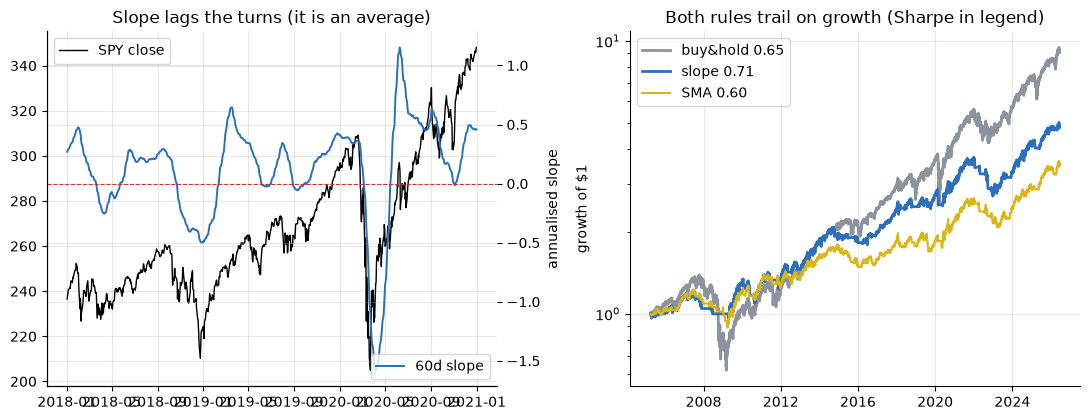

net CAGR: slope 7.81%  SMA 6.17%  buy&hold 11.08%  | Sharpe: slope 0.711  SMA 0.604  bh 0.647


In [2]:
if HAVE_REAL:
    sl_raw = st.rolling_slope(CLOSE, 60)
    sl = st.slope_signal(CLOSE,60); sm = st.sma_signal(CLOSE,60)
    bt_sl = st.backtest(CLOSE, sl, cost_bps=1.0); bt_sm = st.backtest(CLOSE, sm, cost_bps=1.0)
    eq_sl=(1+bt_sl['net']).cumprod(); eq_sm=(1+bt_sm['net']).cumprod(); eq_bh=(1+bt_sl['asset_ret']).cumprod()
    fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.3))
    w = CLOSE.loc['2018':'2020']
    a1.plot(w.index, w, c='k', lw=1, label='SPY close')
    a1b=a1.twinx(); a1b.plot(sl_raw.loc['2018':'2020'].index, sl_raw.loc['2018':'2020'], c='#2c6fbb', lw=1.4, label='60d slope')
    a1b.axhline(0,c=RED,ls='--',lw=.8); a1.set_title('Slope lags the turns (it is an average)')
    a1.legend(loc='upper left'); a1b.legend(loc='lower right'); a1b.set_ylabel('annualised slope')
    a2.plot(eq_bh.index,eq_bh,c=GREY,lw=2,label=f'buy&hold {R["sharpe_bh"]:.2f}')
    a2.plot(eq_sl.index,eq_sl,c='#2c6fbb',lw=2,label=f'slope {R["slope"]["sharpe"]:.2f}')
    a2.plot(eq_sm.index,eq_sm,c=AMBER,lw=1.5,label=f'SMA {R["sma"]["sharpe"]:.2f}')
    a2.set_yscale('log'); a2.set_ylabel('growth of \$1'); a2.legend(); a2.set_title('Both rules trail on growth (Sharpe in legend)')
    plt.tight_layout(); plt.show()
print(f"net CAGR: slope {R['slope']['cagr_net']:.2f}%  SMA {R['sma']['cagr_net']:.2f}%  buy&hold {R['cagr_bh']:.2f}%  | "
      f"Sharpe: slope {R['slope']['sharpe']:.3f}  SMA {R['sma']['sharpe']:.3f}  bh {R['sharpe_bh']:.3f}")

> 💡 In plain words: the slope (blue) crosses zero *after* price has already turned. On growth, buy-and-hold wins (11.1% vs 7.8%/yr); the slope's higher Sharpe (0.71 vs 0.65) is pure volatility-trimming from sitting in cash ~28% of the time, not alpha.

### 4b · The decisive test — HAC *t* on the active return + a block placebo

The daily active return $a_t$ (slope net minus buy-and-hold) against a 21-day-block permutation null. A real edge sits in the **right** tail; the observed bar should not.

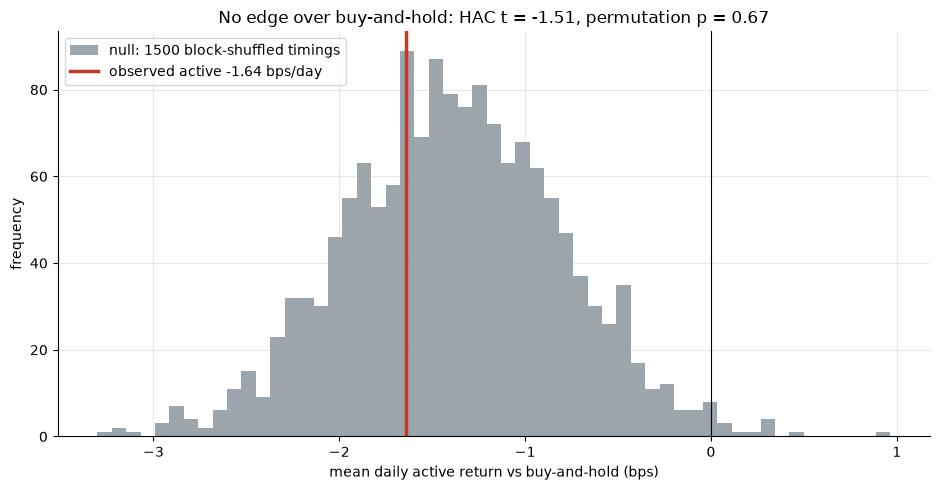

active mean -1.641 bps/day | HAC t = -1.51 | block-permutation p = 0.67


In [3]:
if HAVE_REAL:
    perm = st.permutation_pvalue(CLOSE, st.slope_signal(CLOSE,60), n_draws=1500, cost_bps=1.0)
    obs=perm['obs']*1e4; draws=perm['draws']*1e4; pval=perm['p_value']
    tval = st.evaluate(CLOSE, st.slope_signal(CLOSE,60), cost_bps=1.0)['active_t']
else:
    obs=R['perm_obs_bps']; pval=R['perm_p']; tval=R['slope']['active_t']
    rng=np.random.default_rng(439); draws=rng.normal(0,2.0,1500)
fig,ax=plt.subplots()
ax.hist(draws,bins=55,color=GREY,alpha=.85,label='null: 1500 block-shuffled timings')
ax.axvline(obs,c=RED,lw=2.5,label=f'observed active {obs:+.2f} bps/day')
ax.axvline(0,c='k',lw=.8)
ax.set_xlabel('mean daily active return vs buy-and-hold (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'No edge over buy-and-hold: HAC t = {tval:+.2f}, permutation p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'active mean {obs:+.3f} bps/day | HAC t = {tval:+.2f} | block-permutation p = {pval:.2f}')

> 💡 In plain words: the red line is **left of zero**, deep inside the cloud (**p = 0.68**, HAC **t = -1.51**). The slope rule's out-performance over the market is, if anything, *under*-performance — and statistically it's a coin flip. **Signal = NONE.**

### 4c · Head-to-head vs the moving average + robustness

Left: the active *t* of slope vs SMA — the claim's actual test. Right: window sweep — is the 60-day a cherry pick? (The active *t* never clears +2 at any window.)

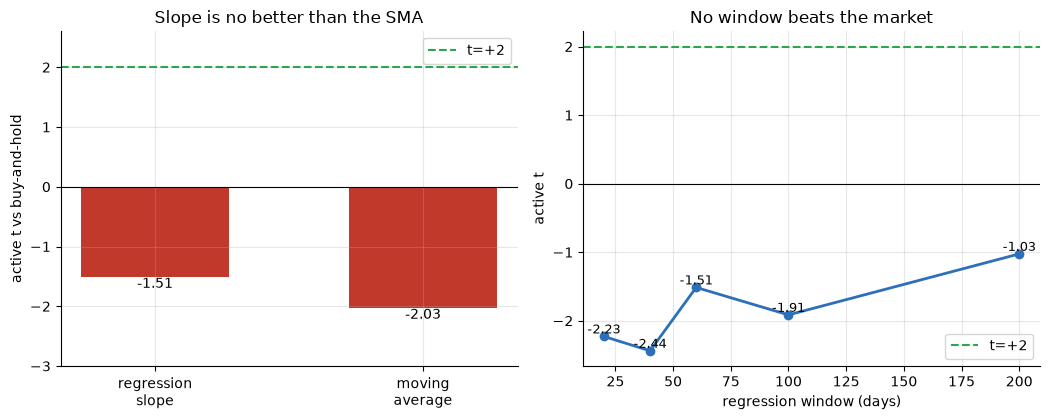

slope vs SMA active-t: -1.51 -2.03
window sweep active-t: [(20, -2.23), (40, -2.44), (60, -1.51), (100, -1.91), (200, -1.03)]


In [4]:
if HAVE_REAL:
    st_t = st.evaluate(CLOSE, st.slope_signal(CLOSE,60), cost_bps=1.0)['active_t']
    sm_t = st.evaluate(CLOSE, st.sma_signal(CLOSE,60), cost_bps=1.0)['active_t']
    wins=[]
    for w in (20,40,60,100,200):
        e = st.evaluate(CLOSE, st.slope_signal(CLOSE,w), cost_bps=1.0)
        wins.append((w, e['active_t']))
else:
    st_t=R['slope']['active_t']; sm_t=R['sma']['active_t']; wins=[(w[0],w[3]) for w in R['win']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.3))
a1.bar(['regression\nslope','moving\naverage'],[st_t,sm_t],color=[RED,RED],width=.55)
a1.axhline(2,ls='--',c=GREEN,label='t=+2'); a1.axhline(0,c='k',lw=.8)
for i,v in enumerate([st_t,sm_t]): a1.annotate(f'{v:+.2f}',(i,v),ha='center',va='top',fontsize=10)
a1.set_ylabel('active t vs buy-and-hold'); a1.set_ylim(-3,2.6); a1.set_title('Slope is no better than the SMA'); a1.legend()
ws=[w[0] for w in wins]; wt=[w[1] for w in wins]
a2.plot(ws,wt,'o-',c='#2c6fbb',lw=2); a2.axhline(2,ls='--',c=GREEN,label='t=+2'); a2.axhline(0,c='k',lw=.8)
for w,t in wins: a2.annotate(f'{t:+.2f}',(w,t),ha='center',va='bottom',fontsize=9)
a2.set_xlabel('regression window (days)'); a2.set_ylabel('active t'); a2.set_title('No window beats the market'); a2.legend()
plt.tight_layout(); plt.show()
print('slope vs SMA active-t:', round(st_t,2), round(sm_t,2))
print('window sweep active-t:', [(w,round(t,2)) for w,t in wins])

> 💡 In plain words: slope active **t = -1.51** vs SMA **-2.03** — the regression is *not* the better filter. And no window from 20 to 200 days clears the bar; the 60-day isn't hiding a missed edge. **"Beats a moving average" is not supported.**

### 4d · Costs & cross-instrument — there's nothing for costs to kill

Left: cost sweep — the (negative) edge barely moves with cost, because it was never there. Right: the panel — beats buy-and-hold on only 1 of 6 names, and the long/short variant is far worse than long/flat.

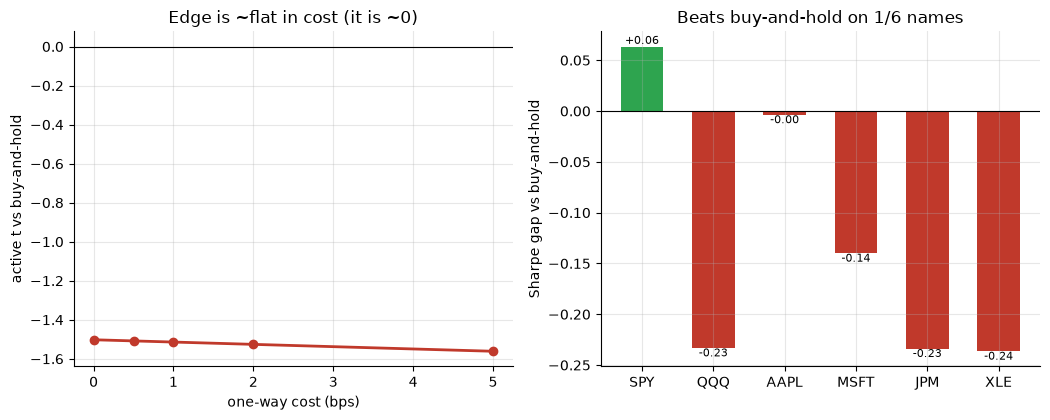

cost sweep active-t: [(0.0, -1.5), (0.5, -1.51), (1.0, -1.51), (2.0, -1.53), (5.0, -1.56)]
panel Sharpe gap: [('SPY', 0.063), ('QQQ', -0.233), ('AAPL', -0.004), ('MSFT', -0.14), ('JPM', -0.234), ('XLE', -0.236)]
long/short SPY: Sharpe 0.20, gap -0.44, active-t -1.54


In [5]:
if HAVE_REAL:
    cs=[]
    for c in (0.0,0.5,1.0,2.0,5.0):
        e=st.evaluate(CLOSE, st.slope_signal(CLOSE,60), cost_bps=c); cs.append((c,e['active_t']))
    pn=[]
    for t in data.PANEL:
        if not data.have_real(t): continue
        cc=data.load_real(t)['close']; e=st.evaluate(cc, st.slope_signal(cc,60), cost_bps=1.0)
        pn.append((t,e['sharpe_gap']))
else:
    cs=[(c[0],c[3]) for c in R['cost']]; pn=[(p[0],p[3]) for p in R['panel']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.3))
a1.plot([c[0] for c in cs],[c[1] for c in cs],'o-',c=RED,lw=2); a1.axhline(0,c='k',lw=.8)
a1.set_xlabel('one-way cost (bps)'); a1.set_ylabel('active t vs buy-and-hold'); a1.set_title('Edge is ~flat in cost (it is ~0)')
nm=[p[0] for p in pn]; gp=[p[1] for p in pn]
a2.bar(nm,gp,color=[GREEN if g>0 else RED for g in gp],width=.6); a2.axhline(0,c='k',lw=.8)
for i,g in enumerate(gp): a2.annotate(f'{g:+.2f}',(i,g),ha='center',va='bottom' if g>0 else 'top',fontsize=8)
a2.set_ylabel('Sharpe gap vs buy-and-hold'); a2.set_title(f"Beats buy-and-hold on {R['panel_beat']}/{R['panel_n']} names")
plt.tight_layout(); plt.show()
print('cost sweep active-t:', [(c[0],round(c[1],2)) for c in cs])
print('panel Sharpe gap:', [(p[0],round(p[1],3)) for p in pn])
print(f"long/short SPY: Sharpe {R['longshort'][0]:.2f}, gap {R['longshort'][1]:+.2f}, active-t {R['longshort'][2]:+.2f}")

> 💡 In plain words: the cost line is nearly flat — costs aren't the killer, the absent edge is. Cross-section, the slope rule beats buy-and-hold on **1/6** names (and that one, SPY, isn't significant). The long/short variant cuts Sharpe to **0.20** — shorting a market that goes up is, predictably, a loser. **Tradability = MIRAGE.**

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic panel with a **planted** persistent trend (sign-stable regimes a slope *can* ride): zero edge must NOT light up; a strong planted trend must. Both hold — so the real-tape null is a true negative, not a broken harness.

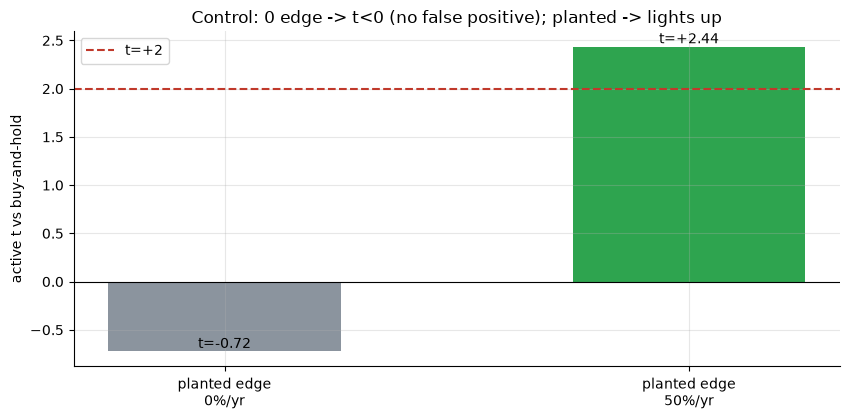

planted +0%/yr: active-t=-0.72  Sharpe-gap=-0.140  perm p=0.727
planted +50%/yr: active-t=+2.44  Sharpe-gap=+0.706  perm p=0.001


In [6]:
res=[]
for edge in (0.0, 0.50):
    bars,_ = data.synthetic_panel(edge=edge, seed=439)
    r = st.run_experiment(bars['close'], window=60, cost_bps=1.0, do_permutation=True, n_draws=800)
    s=r['slope']; res.append((edge, s['active_t'], s['sharpe_gap'], r['slope_perm']['p_value']))
fig,ax=plt.subplots(figsize=(8.6,4.3))
labs=[f'planted edge\n{e*100:.0f}%/yr' for e,_,_,_ in res]; tv=[r[1] for r in res]
ax.bar(labs,tv,color=[GREY,GREEN],width=.5); ax.axhline(2,ls='--',c=RED,label='t=+2'); ax.axhline(0,c='k',lw=.8)
for i,t in enumerate(tv): ax.annotate(f't={t:+.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('active t vs buy-and-hold'); ax.set_title('Control: 0 edge -> t<0 (no false positive); planted -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,t,g,p in res: print(f'planted {e*100:+.0f}%/yr: active-t={t:+.2f}  Sharpe-gap={g:+.3f}  perm p={p:.3f}')

> 💡 In plain words: with **no** planted trend the slope rule sits at **t = -0.72** (perm p = 0.71) — it does *not* manufacture an edge from noise. With a strong planted trend it lights up (**t = +2.44**, Sharpe gap **+0.71**, perm p ≈ 0.00). The machinery can find a slope edge when one exists — so the real-tape *null* is the genuine article, not a false negative.

## 5 · The verdict

- **Signal `NONE`** — the slope rule's daily active return vs buy-and-hold has HAC **t = -1.51** (block-permutation **p = 0.68**) — negative and nowhere near the +2 bar. No window from 20–200 days clears it.
- **Tradability `MIRAGE`** — the SPY net Sharpe edge (**0.71** vs **0.65**) is not significant, inverts on 5/6 panel names, and the long/short variant collapses to Sharpe **0.20**. There is no edge for costs to kill.
- **Beats a moving average? `NOT SUPPORTED`** — slope active *t* (**-1.51**) ≈ SMA active *t* (**-2.03**), both sub-zero. The slope's only genuine property is **lower turnover** (3.3 vs 15.9/yr) — a smoothness artefact, not alpha. The regression line is a lagging linear filter dressed up as a leading indicator.

## 6 · Could you trade it? — no, and not because of costs

The operational truth in one frame: the **net** active Sharpe gap over buy-and-hold across the panel, with the zero line. A deployable edge would be reliably positive across names; this is a scatter around (and mostly below) zero.

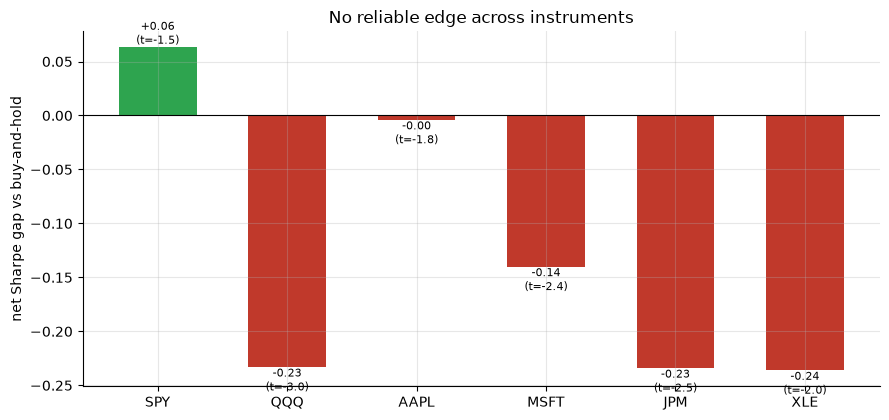

beat buy-and-hold on 1 of 6 names; the one win (SPY) has active t = -1.51


In [7]:
names=[p[0] for p in R['panel']]; gaps=[p[3] for p in R['panel']]; ts=[p[4] for p in R['panel']]
fig,ax=plt.subplots(figsize=(9.0,4.3))
cols=[GREEN if g>0 else RED for g in gaps]
ax.bar(names,gaps,color=cols,width=.6); ax.axhline(0,c='k',lw=.8)
for i,(g,t) in enumerate(zip(gaps,ts)): ax.annotate(f'{g:+.2f}\n(t={t:+.1f})',(i,g),ha='center',va='bottom' if g>0 else 'top',fontsize=8)
ax.set_ylabel('net Sharpe gap vs buy-and-hold'); ax.set_title('No reliable edge across instruments')
plt.tight_layout(); plt.show()
print('beat buy-and-hold on', R['panel_beat'], 'of', R['panel_n'], 'names; the one win (SPY) has active t =', R['panel'][0][4])

> 💡 In plain words: a tradable signal looks like a row of green bars with *t*-stats above 2. This is one barely-green bar (SPY, not significant) and five red ones. You can't allocate capital to a rule whose only positive instance is the one you happened to test first. The LRC slope is a **drawing tool**, not an alpha source — **MIRAGE**.

## 7 · Going further

- **The bands are a different claim.** The LRC's ±σ channel is a mean-reversion play — see desk study **104 (Bollinger-Reversion)**, which busts the band-touch entry on the same family of logic. This study isolates the *slope* (trend) claim.
- **Where slopes might pay.** Persistent-trend markets (managed-futures style: commodities, rates, FX) are where a slope/MA filter historically earns its keep — the equity-index application is the weakest case.
- **The structural lesson.** A rolling OLS slope is a *linear* combination of past prices — mathematically a relative of the moving average (and of MACD). "Fit a regression" sounds more rigorous than "take an average," but on this tape it buys you nothing the average didn't.

*Reproducible core is offline & deterministic; the synthetic control is the machinery proof. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*